In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression,LogisticRegression
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier,KNeighborsRegressor
from sklearn.ensemble import RandomForestClassifier,RandomForestRegressor
from sklearn.metrics import accuracy_score,confusion_matrix,f1_score,recall_score,precision_score
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler


## Train Test Split:

In [18]:
df=pd.read_csv('c:/Users/A/Intenship/Credit Card Approval Prediction System/clean_dataset.csv')
df

,Gender,Age,Debt,Married,BankCustomer,Industry,PriorDefault,Employed,CreditScore,DriversLicense,...,ZipCode,Income,Approved,Gender_Encoder,BankCustomer_Encoder,Married_Encoder,Approved_encoder,PriorDefault_Encoder,Employed_Encoder,DriversLicense_Encoder
0,Female,40.17,9.92,Yes,Yes,Financials,Yes,Yes,21.0,Yes,...,9524,26047.0,Approved,0,1,1,0,1,1,1
1,Female,47.61,5.01,No,Yes,CommunicationServices,Yes,No,19.0,No,...,62249,73958.0,Rejected,0,1,0,1,1,0,0
2,Male,23.00,9.26,No,Yes,Utilities,No,Yes,64.0,Yes,...,26621,42632.0,Approved,1,1,0,0,0,1,1
3,Female,30.67,22.60,No,No,Energy,Yes,Yes,33.0,Yes,...,40799,90289.0,Approved,0,0,0,0,1,1,1
4,Male,24.93,1.87,No,Yes,Research,Yes,No,29.0,Yes,...,95060,4208.0,Rejected,1,1,0,1,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6779,Male,68.59,7.79,Yes,Yes,Energy,No,Yes,42.0,No,...,34963,59812.0,Rejected,1,1,1,1,0,1,0
6780,Female,53.36,1.87,No,Yes,communicationservices,Yes,Yes,14.0,Yes,...,8000,21611.0,Approved,0,1,0,0,1,1,1
6781,Male,40.59,18.94,No,No,Transport,Yes,Yes,60.0,Yes,...,76164,91198.0,Approved,1,0,0,0,1,1,1
6782,Female,30.98,22.76,Yes,Yes,CommunicationServices,Yes,Yes,33.0,No,...,11225,72413.0,Approved,0,1,1,0,1,1,0


In [19]:
x=df[['Gender_Encoder','PriorDefault_Encoder','Employed_Encoder','DriversLicense_Encoder','Age','Debt','BankCustomer_Encoder','Married_Encoder','Income','ZipCode']]
y=df['Approved_encoder']

In [20]:
X_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)


In [21]:
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(x_test)

## Model Selection

    ## Logistic Regression

In [22]:
lr=LogisticRegression(solver='liblinear', max_iter=1000, C=1.0)
lr.fit(X_train_sc,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,1000
,multi_class,'deprecated'


In [23]:
y_pred_lr=lr.predict(X_test_sc)

In [24]:
print("======= Logistic Regression =======")
print("Accuracy :", round(accuracy_score(y_test, y_pred_lr) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_lr, average='weighted') * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_lr, average='weighted') * 100, 2), "%")
print("F1-Score :", round(f1_score(y_test, y_pred_lr, average='weighted') * 100, 2), "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_lr))

======= Logistic Regression =======
Accuracy : 85.95 %
Precision: 85.94 %
Recall   : 85.95 %
F1-Score : 85.92 %
Confusion Matrix:
 [[997 126]
 [160 753]]


## Decision Tree 

In [25]:
dt = DecisionTreeClassifier(max_depth=5, criterion='entropy', min_samples_split=10,random_state=42)
dt.fit(X_train, y_train)

# Predict
y_pred_dt = dt.predict(x_test)

# Metrics
print("======= Decision Tree =======")
print("Accuracy :", round(accuracy_score(y_test, y_pred_dt) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_dt, average='weighted') * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_dt, average='weighted') * 100, 2), "%")
print("F1-Score :", round(f1_score(y_test, y_pred_dt, average='weighted') * 100, 2), "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_dt))

======= Decision Tree =======
Accuracy : 85.31 %
Precision: 85.33 %
Recall   : 85.31 %
F1-Score : 85.26 %
Confusion Matrix:
 [[1000  123]
 [ 176  737]]


## Random Forest 

In [26]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, class_weight='balanced')
rf.fit(X_train, y_train)

# Predict
y_pred_rf = rf.predict(x_test)

In [27]:
print("======= Random Forest =======")
print("Accuracy :", round(accuracy_score(y_test, y_pred_rf) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_rf, average='weighted') * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_rf, average='weighted') * 100, 2), "%")
print("F1-Score :", round(f1_score(y_test, y_pred_rf, average='weighted') * 100, 2), "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_rf))

======= Random Forest =======
Accuracy : 86.39 %
Precision: 86.4 %
Recall   : 86.39 %
F1-Score : 86.4 %
Confusion Matrix:
 [[982 141]
 [136 777]]


## SVC

In [28]:
svm = SVC(kernel='rbf', C=1.0, gamma='scale', probability=True,random_state=42)
svm.fit(X_train_sc, y_train)

# Predict
y_pred_svm = svm.predict(X_test_sc)

In [29]:
print("======= SVM =======")
print("Accuracy :", round(accuracy_score(y_test, y_pred_svm) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_svm, average='weighted') * 100, 2), "%")
print("Recall   :", round(recall_score(y_test, y_pred_svm, average='weighted') * 100, 2), "%")
print("F1-Score :", round(f1_score(y_test, y_pred_svm, average='weighted') * 100, 2), "%")
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred_svm))

======= SVM =======
Accuracy : 86.2 %
Precision: 86.19 %
Recall   : 86.2 %
F1-Score : 86.19 %
Confusion Matrix:
 [[987 136]
 [145 768]]


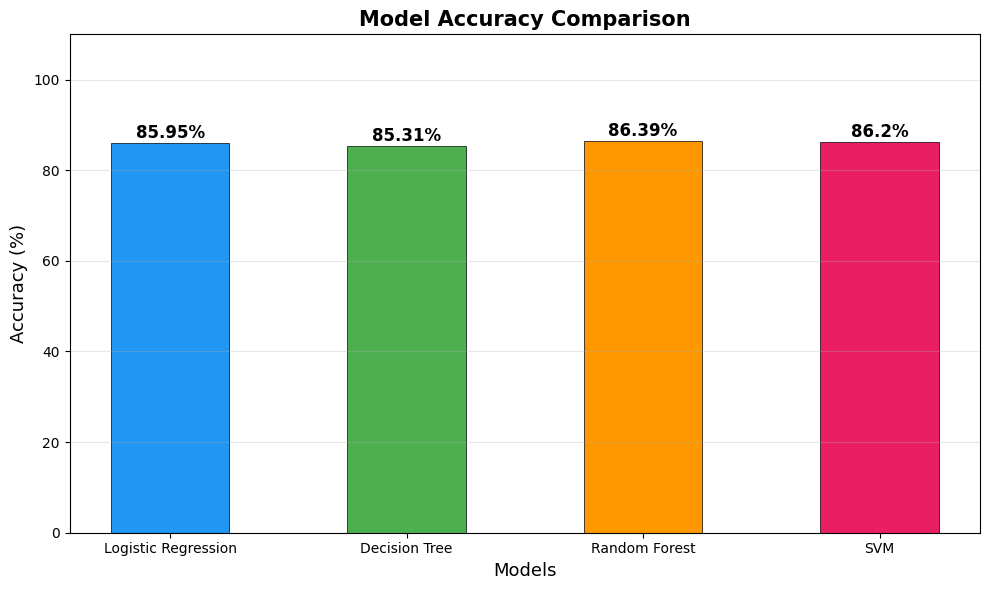

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# ── Data ──────────────────────────────────────────────
models   = ['Logistic Regression', 'Decision Tree',
            'Random Forest', 'SVM']

accuracy = [
    round(accuracy_score(y_test, y_pred_lr)  * 100, 2),
    round(accuracy_score(y_test, y_pred_dt)  * 100, 2),
    round(accuracy_score(y_test, y_pred_rf)  * 100, 2),
    round(accuracy_score(y_test, y_pred_svm) * 100, 2)
]

# ── Colors ────────────────────────────────────────────
colors = ['#2196F3', '#4CAF50', '#FF9800', '#E91E63']

# ── Bar Chart ─────────────────────────────────────────
plt.figure(figsize=(10, 6))

bars = plt.bar(models, accuracy,
               color=colors,
               width=0.5,
               edgecolor='black',
               linewidth=0.5)

# ── Value Labels on Bars ──────────────────────────────
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2.,
             height + 0.3,
             f'{height}%',
             ha='center',
             va='bottom',
             fontsize=12,
             fontweight='bold')

# ── Labels & Title ────────────────────────────────────
plt.xlabel('Models',    fontsize=13)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.title('Model Accuracy Comparison',
          fontsize=15, fontweight='bold')
plt.ylim(0, 110)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150)
plt.show()

In [31]:
model_report = pd.DataFrame({
    'Model Name': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'SVM'],
    'Accuracy': [accuracy_score(y_test, y_pred_lr), accuracy_score(y_test, y_pred_dt), accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_svm)],
    'Precision': [precision_score(y_test, y_pred_lr), precision_score(y_test, y_pred_dt), precision_score(y_test, y_pred_rf), precision_score(y_test, y_pred_svm)],
    'Recall': [recall_score(y_test, y_pred_lr), recall_score(y_test, y_pred_dt), recall_score(y_test, y_pred_rf), recall_score(y_test, y_pred_svm)],
    'F1 Score': [f1_score(y_test, y_pred_lr), f1_score(y_test, y_pred_dt), f1_score(y_test, y_pred_rf), f1_score(y_test, y_pred_svm)]
})
model_report

,Model Name,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.859528,0.856655,0.824754,0.840402
1,Decision Tree,0.853143,0.856977,0.807229,0.831359
2,Random Forest,0.863949,0.846405,0.851041,0.848717
3,SVM,0.861984,0.849558,0.841183,0.845349


In [32]:
import pickle

filename = 'credit_card_model.pkl'
pickle.dump(rf, open(filename, 'wb'))

# Also save your scaler if you used one (e.g., 'scaler')
pickle.dump(scaler, open('scaler.pkl', 'wb'))